# Vanilla Transformer PoC

link: https://medium.com/towards-data-science/paper-walkthrough-attention-is-all-you-need-80399cdc59e1

# Introduction

RNN-based models before transformer like LSTM and GRU captured context in "sequential manner"

"Attention mechanism allows the Tranformer mechanism to freely "attend" to the parts it considers important without being constrained by sequential processing." 굳이 순차성에 얽매이지 않아도 된다.

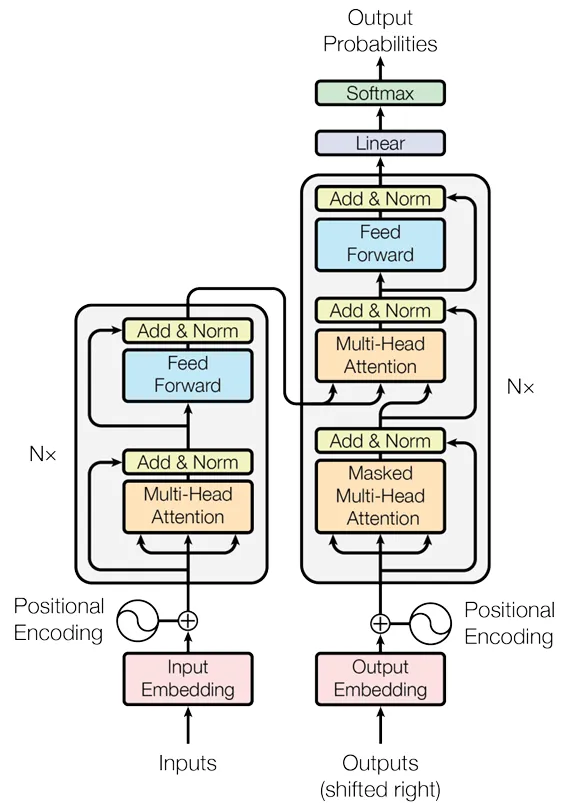

# Architecture Overview

Main Blocks)
- Encoder: capture the pattern of the original sentence
- Decoder: generate the corresponding translation. Uses the output of the encoder in the second multi-head attention.

Elements)

- Multi-Head Attention: compares each word with every other word within the sequence

- Positional Encoding: sequence information calculation

- Add & Norm: addition and normalization

- Feed Forward:  
attention은 단순히 개별 token을 서로 간의 관계로 잘 표현한 것이고,  
이것이 최종 output에 어떻게 영향을 미칠 것인지는 별도의 비선형적(linear를 relu에 통과시킴)으로 또 연산

- Input & Output Embedding: convert words into vectors

- final Softmax: probability distribution to predict the next word

- Outputs (Shifted Right):
  1. When Training: There is the input and the target output. While the encoder just takes in the input (like the whole sentence), the decoder will start with 0 words, and start to increase the number of words it can see one at a time. Other not allowed words will be 'masked'. The decoder therefore runs as many times as the number of words in the sentence.
  
  2. When Inference(predicting): The transformer model outputs a single word at a time. While the encoder just takes in the input (like the whole sentence), the decoder will rerun based on the former output, which is a single word. The decoder therefore runs as many times as the number of words in the sentence. The first time the decoder runs, the word will just be an empty place holder like token.





# Positional Encoding

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

<br>

- $d_{model}$ : 입력 토큰(단일 스칼라)이 변환되는 벡터의 길이  

- $i$ : $0$부터 $d_{model} - 1$까지의 숫자를 차례대로 넣음  

<br>

## 예시

"고양이", "앉아", "있다"를 4차원으로 embedding할 경우:

$$
pos = 0, 1, 2
$$

$$
d_{model} = 4
$$

<br>

"고양이"는 $pos=0$ 이므로:

$$
PE(0, 0) = \sin(0) = 0
$$


$$
PE(0, 1) = \cos(0) = 1
$$


$$
PE(0, 2) = \sin(0) = 0
$$


$$
PE(0, 3) = \cos(0) = 1
$$

<br>

"고양이" 토큰 ($pos=0$) 의 embedding은:
$$
PE(0) = [0, 1, 0, 1]
$$

## Multi-Head Attention

### 1) (Single) Attention Mechanism  

$$
Q_i = XW_Q, \quad K_i = XW_K, \quad V_i = XW_V
$$

$$ Attention(Q_i, K_i, V_i) = \text{softmax}\left(\frac{Q_i K_i^T}{\sqrt{d_k}}\right)V_i $$  

- Positional Encoding에서 받은 벡터를 $X$라고 한다면, Query, Key, Value 각각에 맞는 학습가능한 행렬 $W$ 를 곱해서 변환해준다.



- $ d_k $: $d_k = \frac{d_{model}}{\text{number of heads}}$ 를 주로 사용한다.
- $d_{model}$ 는 X의 길이, number of heads는 multi-head attention의 head 개수!
- $QK^T$는 단순곱이라서 차원이 커지면 계속 커지기 때문에 $d_k$로 값을 내려준다

<br>

### 2) 핵심 아이디어: Token 간 관계 파악

Attention 메커니즘: "sequence 내에서 본 토큰과 다른 토큰의 관계를 질문(Query)하고, 일치하는 답변(Key)을 찾아내는 과정"
- Query: 현재 토큰이 다른 토큰과 어떤 관계를 맺고 싶은지 "질문".
- Key: 다른 토큰이 제공할 수 있는 "답변".
- Value: 해당 토큰이 가진 고유한 값.

이를 위해:
1. Query와 Key를 dot product로 단순히 곱해서 관계 점수를 얻는다.
2. 점수를  softmax로 변환하여 확률 분포로 만듭니다.
3. Value를 가중합(weighted sum, $W^O$)하여 최종 출력 값을 계산합니다.  

<br>

### 3) Softmax 함수

softmax 함수는 확률분포를 만들어준다. (exp는 자연상수 $e$의 지수(exponent)가 된다는 뜻).  

$$\text{softmax}(x_i) = \frac{\exp(x_i)}{\sum_{j=1}^{n} \exp(x_j)}$$  


<br>

### (4) Multi-Head Attention

각 Attention의 결과값이 하나의 head가 되며, 아래처럼 단순히 가로로 concat해서 이어붙인다.  

최종적으로 $ W^O $를 통해 모든 헤드의 출력을 하나로 통합한다!  


$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \text{head}_2, \dots, \text{head}_h)W^O
$$


<br>

### (5) 정리

1. Attention 메커니즘은 Query, Key, Value를 사용해 토큰 간 관계를 계산. <br>
2. Multi-Head Attention은 여러 Attention을 이어붙여 다양한 관계를 포착. <br>
3. 각 Head의 결과를 결합(Concat)하고 학습 가능한 가중치 $ W^O $로 최종 출력 값을 만든다. <br>